# Lesson 4 — From EEG to Features: Understanding Alpha Power

**Required · real-recording replay · about 60 minutes**

Lesson 3 asked which data could pass a quality gate. Now we ask:
**How can an accepted EEG interval become an interpretable number?**

**Real EEG → accepted continuous interval → PSD → Alpha-band area → Alpha over time.**

By the end, you can explain and calculate **absolute Alpha power**, distinguish
it from a PSD value, and plot it without hiding rejected intervals. The course
uses 8–13 Hz as its fixed Alpha band. Band power can be calculated even when
there is no distinct rhythmic peak; we do not force a 10 Hz result.

This notebook retains the Welch computation from the supplied S2 analysis,
with a documented input adapter for Lesson 3's quality masks. It generates
**four figures**. A real recording is required; there is no synthetic fallback.

**VS Code:** select `neuradock_env` (or your course Python environment), then
**Run All**. You do not need to run another notebook first: the same reader
and gate are called here. Start with the defaults; then try another eligible
channel or accepted window. Lesson 5 turns this feature into a feedback loop.


In [1]:
from pathlib import Path
import hashlib
import json
import os
import sys

locations = (Path.cwd(), Path.cwd() / "neuradock-eeg-101", *Path.cwd().parents)
ROOT = next((p for p in locations if (p / "src" / "neuradock_eeg101").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Open the neuradock-eeg-101 project folder in VS Code first.")
sys.path.insert(0, str(ROOT / "src"))
IN_NOTEBOOK = "ipykernel" in sys.modules
if IN_NOTEBOOK:
    get_ipython().run_line_magic("matplotlib", "inline")
else:
    os.environ.setdefault("MPLBACKEND", "Agg")
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.integrate import trapezoid
from neuradock_eeg101.reading import data_reader, inspect_timing, describe_p_field
from neuradock_eeg101.quality_gate import run_quality_gate
from neuradock_eeg101.alpha_features import FIXED_FS, analyze_alpha_windows, integrate_band

OUTPUT_DIR = ROOT / "outputs" / "notebooks" / "lesson-04"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES = []
plt.rcParams.update({"font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False})

def show_and_save(fig, filename):
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=150, bbox_inches="tight", facecolor="white")
    FIGURES.append(filename)
    if IN_NOTEBOOK:
        plt.show()
    plt.close(fig)


## 1. Start with data that passed the gate · 10 min

Use the same real file as Lessons 2–3. The values in the two supplied S2 files
were confirmed to be **µV** by the owner on 2026-09-21. Only their exact file
hashes inherit that confirmation. For a different file, verify its units and
acquisition rate; set `UNIT_CONFIRMED = True` only if it already contains µV.

Keep the generic labels `Ch1`–`Ch7`. We have not confirmed the historical
electrode montage or the experimental conditions of these files. Do not
rename this result “posterior Alpha” or label the file “eyes closed”.

The gate is unchanged: the original 1–50 Hz offline filter and three checks
from Lesson 3. Reuse its **filtered array and masks**. We do not filter a
second time, rescale amplitudes, or overwrite the recording.


In [2]:
TEACHING_FILE = ROOT / "data" / "teaching" / "lesson-02" / "recording-01.txt"
LOCAL_ORIGINAL = ROOT.parent / "S2" / "S04_01.txt"
default_file = TEACHING_FILE if TEACHING_FILE.is_file() else LOCAL_ORIGINAL
DATA_PATH = Path(os.environ.get("NEURADOCK_LESSON04_FILE",
                 os.environ.get("NEURADOCK_LESSON03_FILE",
                 os.environ.get("NEURADOCK_LESSON02_FILE", str(default_file)))))
if not DATA_PATH.is_absolute():
    DATA_PATH = ROOT / DATA_PATH
DATA_PATH = DATA_PATH.resolve()
if not DATA_PATH.is_file():
    raise FileNotFoundError(
        "Lesson 4 requires a real recording. Set DATA_PATH or NEURADOCK_LESSON04_FILE "
        "to your authorized file. No synthetic substitute will be used.")
if (ROOT / "data" / "synthetic").resolve() in DATA_PATH.parents:
    raise ValueError("Lesson 4 requires real data, not a bundled synthetic recording.")
SOURCE_SHA256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
CONFIRMED_UV_HASHES = {
    "1c7cf69cf4572aa96b3452f2febb176c8c2a024eaf0e95812b22edda881006bb",
    "23a8e68b331a86ed7eb79056b580a972bdb9ee74d189e881316f0c7ead35db54",
}
UNIT_CONFIRMED = None  # None = use confirmed hashes; True/False = explicit confirmation.
unit_confirmed = (SOURCE_SHA256 in CONFIRMED_UV_HASHES
                  if UNIT_CONFIRMED is None else UNIT_CONFIRMED)
if not isinstance(unit_confirmed, bool):
    raise ValueError("UNIT_CONFIRMED must be None, True, or False.")
if os.environ.get("NEURADOCK_LESSON04_VERIFY") == "1":
    OUTPUT_DIR = OUTPUT_DIR / "verification" / SOURCE_SHA256[:12]
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FS = 250  # Declared acquisition rate; not a parameter to tune for a result.
CHANNEL_NAMES = [f"Ch{i + 1}" for i in range(7)]
CHANNEL_INDEX = None  # None = first eligible column; otherwise a zero-based eligible index.
EXAMPLE_WINDOW = 0  # Index in the list of accepted feature windows; 0 = the first one.
FEATURE_WINDOW_S = 4.0  # Four-second feature window, shifted by one second.
STEP_S = 1.0
WELCH_S = 2.0  # Original S2 Welch segment: 2 s = 500 samples, with default 50% overlap.
ALPHA_BAND = (8.0, 13.0)
print("File:", DATA_PATH.name, "| Mode: real-recording replay | µV confirmed:", unit_confirmed)


File: recording-01.txt | Mode: real-recording replay | µV confirmed: True


In [3]:
if not unit_confirmed:
    raise ValueError("Alpha power requires confirmed µV input. Verify units before setting UNIT_CONFIRMED=True.")
data, info = data_reader(DATA_PATH)
n_channels, n_samples = data.shape
gate = run_quality_gate(data, fs=FS, unit_confirmed=unit_confirmed)
filtered = gate["filtered"]
keep_mask = gate["keep_mask"]
bad_channel_mask = gate["bad_channel_mask"]
eligible_indices = np.flatnonzero(~bad_channel_mask)
timing = inspect_timing(info["raw_timestamps"], timestamp_format="clock_hms_ms")
p_summary = describe_p_field(info["p_fields"])
time_s = np.arange(n_samples) / FS
print("QUALITY STATUS:", gate["summary"]["status"])
print("Bad-channel candidates:", gate["summary"]["bad_channel_labels"] or "none")
print("Accepted nominal duration:", keep_mask.sum() / FS, "s")
print("Unassessed tail:", gate["summary"]["unassessed_tail_samples"], "samples")
print("Repeated/backward clock intervals:", timing["nonpositive_interval_count"],
      "| Maximum interval:", timing["maximum_packet_interval_s"], "s")
print("This is heuristic screening, not a certificate of artifact-free brain activity.")
print("Times remain nominal sample index / 250; no clock interpolation or event inference.")
if not len(eligible_indices) or not keep_mask.any():
    raise ValueError("No eligible data remain after Lesson 3 gating. Inspect or reacquire; do not relax QC to force a result.")
ch = int(eligible_indices[0]) if CHANNEL_INDEX is None else CHANNEL_INDEX
if isinstance(ch, bool) or not isinstance(ch, int) or ch not in eligible_indices:
    raise ValueError(f"Choose an eligible zero-based CHANNEL_INDEX: {eligible_indices.tolist()}")
print("Displayed channel:", CHANNEL_NAMES[ch], "(first eligible column by default, not strongest Alpha)")


QUALITY STATUS: warning
Bad-channel candidates: ['Ch1', 'Ch3', 'Ch5', 'Ch7']
Accepted nominal duration: 61.0 s
Unassessed tail: 18 samples
Repeated/backward clock intervals: 205 | Maximum interval: 0.04200000000128057 s
This is heuristic screening, not a certificate of artifact-free brain activity.
Times remain nominal sample index / 250; no clock interpolation or event inference.
Displayed channel: Ch2 (first eligible column by default, not strongest Alpha)


### The PSD code comes from the supplied S2 analysis

The original `calculate_eeg_psd()` reads a file, selects data, and loops over
channels with `welch(channel_data, fs=fs, nperseg=fs*2)`. The function below
preserves that per-channel Welch calculation. It is an **adaptation**, not
a verbatim copy of the whole original function: its input is now one already
accepted continuous interval, and it refuses intervals shorter than the
requested Welch segment. It does not invoke the older `data_selecter()`.

The small validation helpers are imported; the calculation itself is visible.
The window-management helper keeps gaps and channel exclusions explicit.
See `docs/lesson04-source.md` for the original source identity and changes.


In [4]:
from neuradock_eeg101.alpha_features import _fixed_fs, _sample_count

def calculate_segment_psd(
    segment: np.ndarray, *, fs: int = FIXED_FS, welch_s: float = 2.0
) -> tuple[np.ndarray, np.ndarray]:
    """Return channels × frequencies, preserving S2's per-channel Welch loop.

    The input is one uninterrupted, already-filtered segment; the function does
    not select samples, join gaps, resample, or apply another filter.
    """
    fs = _fixed_fs(fs)
    nperseg = _sample_count(welch_s, fs, "welch_s")
    matrix = np.asarray(segment, dtype=float)
    if matrix.ndim != 2 or matrix.shape[0] < 1:
        raise ValueError("segment must have shape (channels, continuous samples).")
    if matrix.shape[1] < nperseg:
        raise ValueError("segment must contain at least fs * welch_s samples; no silent shortening.")
    if not np.isfinite(matrix).all():
        raise ValueError("segment contains non-finite values.")

    all_channel_psds = []
    freqs = None
    for i in range(matrix.shape[0]):
        channel_data = matrix[i, :]
        f, psd = welch(channel_data, fs=fs, nperseg=nperseg)
        if freqs is None:
            freqs = f
        all_channel_psds.append(psd)
    psd_data = np.array(all_channel_psds)
    return freqs, psd_data


### Three durations with different jobs

- **1 second:** Lesson 3's QC decision interval. This has not changed.
- **4 seconds:** the amount of continuous accepted EEG summarized by one Alpha value.
- **2 seconds:** each internal Welch segment used to estimate its PSD.

Candidate feature windows start at 0, 1, 2, ... seconds. A window is used
only if **every sample passes the gate**. This deliberately strict 100% rule
avoids filling or joining gaps. Windows containing rejected samples or an
unassessed tail are skipped; an incomplete final window is not shortened.
Different experimental blocks must be supplied and processed separately.
“Continuous” here means consecutive recorded sample indices; it does not
certify the accuracy or continuity of the original device clock.

Default selection is the **first eligible channel and first accepted feature
window**, not the window with the strongest Alpha. Adjacent feature windows
overlap, so their count is not an independent trial count or unique duration.


In [5]:
features = analyze_alpha_windows(
    filtered, keep_mask, bad_channel_mask, fs=FS,
    window_s=FEATURE_WINDOW_S, step_s=STEP_S, welch_s=WELCH_S,
    unit_confirmed=unit_confirmed)
valid_indices = np.flatnonzero(features["valid_window_mask"])
if isinstance(EXAMPLE_WINDOW, bool) or not isinstance(EXAMPLE_WINDOW, int) or not 0 <= EXAMPLE_WINDOW < len(valid_indices):
    raise ValueError(f"EXAMPLE_WINDOW must be from 0 to {len(valid_indices) - 1}.")
example_index = int(valid_indices[EXAMPLE_WINDOW])
start = int(features["starts"][example_index])
stop = int(features["stops"][example_index])
segment = filtered[eligible_indices, start:stop]
frequencies, example_psd = calculate_segment_psd(segment, fs=FS, welch_s=WELCH_S)
np.testing.assert_allclose(example_psd, features["psd_by_window"][eligible_indices, example_index, :])
selected_row = int(np.flatnonzero(eligible_indices == ch)[0])
assert keep_mask[start:stop].all()
print("Accepted feature windows:", len(valid_indices), "/", len(features["starts"]))
print("Unique duration covered by feature windows:", features["coverage_mask"].sum() / FS, "s")
print(f"Example interval: [{start / FS:.1f}, {stop / FS:.1f}) nominal seconds")
print("Eligible channel labels:", [CHANNEL_NAMES[i] for i in eligible_indices])
print("No samples were concatenated. More overlapping windows do not create more recorded time.")


Accepted feature windows: 40 / 91
Unique duration covered by feature windows: 55.0 s
Example interval: [19.0, 23.0) nominal seconds
Eligible channel labels: ['Ch2', 'Ch4', 'Ch6']
No samples were concatenated. More overlapping windows do not create more recorded time.


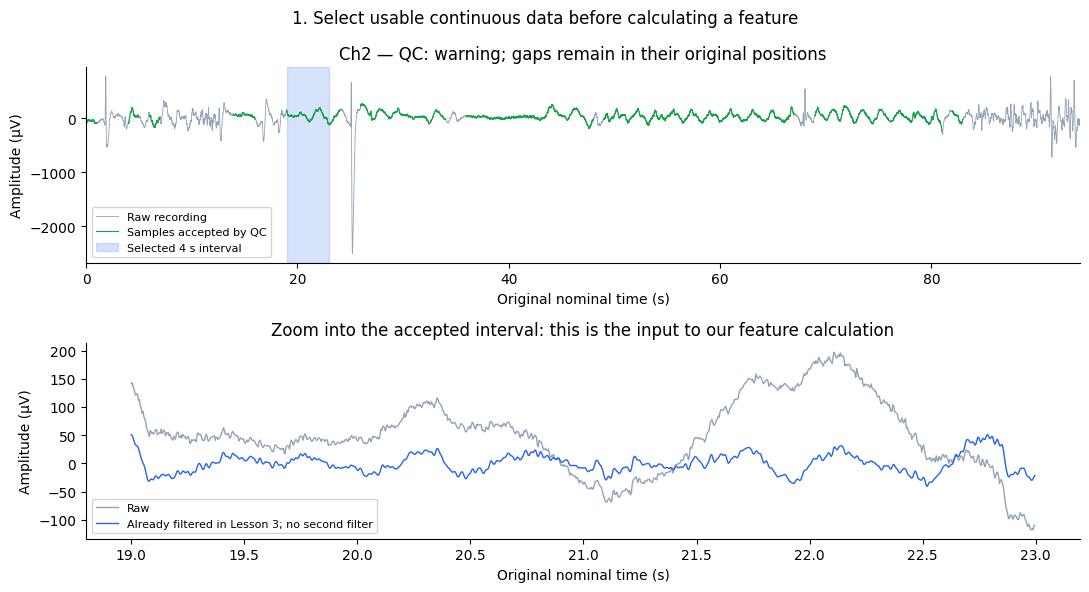

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6))
axes[0].plot(time_s, data[ch], color="#94a3b8", lw=0.6, label="Raw recording")
axes[0].plot(time_s, np.where(keep_mask, data[ch], np.nan),
             color="#16a34a", lw=0.8, label="Samples accepted by QC")
axes[0].axvspan(start / FS, stop / FS, color="#2563eb", alpha=0.18,
                label=f"Selected {FEATURE_WINDOW_S:g} s interval")
axes[0].set(xlim=(0, n_samples / FS), xlabel="Original nominal time (s)", ylabel="Amplitude (µV)",
            title=f"{CHANNEL_NAMES[ch]} — QC: {gate['summary']['status']}; gaps remain in their original positions")
axes[0].legend(fontsize=8)
axes[1].plot(time_s[start:stop], data[ch, start:stop], color="#94a3b8", lw=1, label="Raw")
axes[1].plot(time_s[start:stop], filtered[ch, start:stop], color="#2563eb", lw=1,
             label="Already filtered in Lesson 3; no second filter")
axes[1].set(xlabel="Original nominal time (s)", ylabel="Amplitude (µV)",
            title="Zoom into the accepted interval: this is the input to our feature calculation")
axes[1].legend(fontsize=8)
fig.suptitle("1. Select usable continuous data before calculating a feature")
show_and_save(fig, "01-usable-segment.png")


## 2. From voltage over time to power over frequency · 15 min

The waveform tells us **when the voltage changes**. The PSD tells us **how
power is distributed across frequency**. Welch averages spectra from shorter,
overlapping segments of the accepted interval; it does not turn this
recording into multiple independent trials.

At the defaults, each four-second feature window contains three overlapping
two-second Welch segments. With `FS=250` and `nperseg=500`, frequency-bin spacing
is **0.5 Hz**. Bin spacing is not a guarantee of precise physiological peak
estimation. The window function also affects spectral resolution.

PSD is in **µV²/Hz** when input is in µV. In the next figure, highlight 8–13 Hz
without assuming there must be a narrow peak there.
[Method reference: SciPy Welch documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html).


Welch samples per segment: 500
Frequency-bin spacing: 0.5 Hz


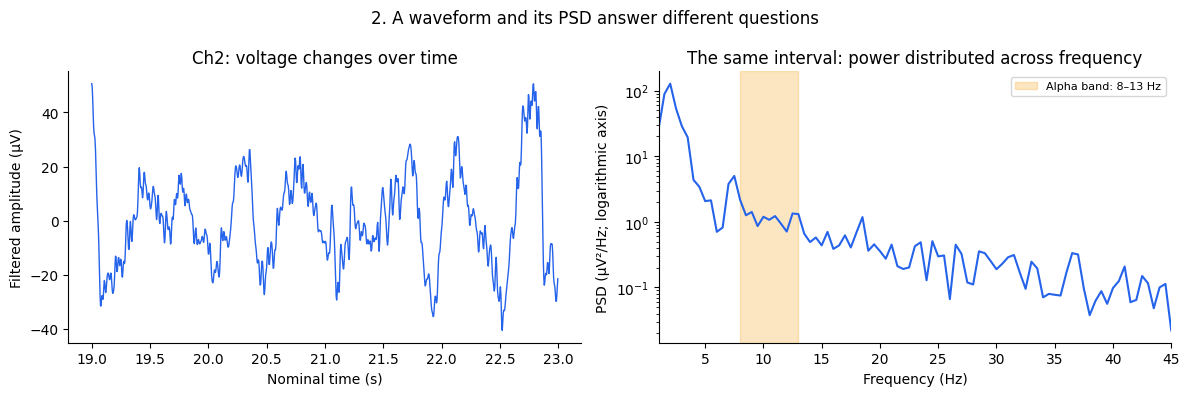

In [7]:
frequency_spacing_hz = float(frequencies[1] - frequencies[0])
print("Welch samples per segment:", int(FS * WELCH_S))
print("Frequency-bin spacing:", frequency_spacing_hz, "Hz")
spectrum = example_psd[selected_row]
display_bins = (frequencies >= 1) & (frequencies <= 45)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(time_s[start:stop], filtered[ch, start:stop], color="#2563eb", lw=1)
axes[0].set(xlabel="Nominal time (s)", ylabel="Filtered amplitude (µV)",
            title=f"{CHANNEL_NAMES[ch]}: voltage changes over time")
axes[1].semilogy(frequencies[display_bins], np.maximum(spectrum[display_bins], 1e-12), color="#2563eb")
axes[1].axvspan(*ALPHA_BAND, color="#f59e0b", alpha=0.25, label="Alpha band: 8–13 Hz")
axes[1].set(xlim=(1, 45), xlabel="Frequency (Hz)", ylabel="PSD (µV²/Hz; logarithmic axis)",
            title="The same interval: power distributed across frequency")
axes[1].legend(fontsize=8)
fig.suptitle("2. A waveform and its PSD answer different questions")
show_and_save(fig, "02-eeg-to-psd.png")


## 3. Turn the Alpha-band area into one feature · 20 min

**Absolute Alpha power = area under the PSD between 8 and 13 Hz.**

We use trapezoidal numerical integration: neighboring frequency bins form
small trapezoids, and their areas are added. PSD has units µV²/Hz; multiplying
by a frequency interval in Hz gives power in **µV²**.

This differs from Lesson 3's upstream **PSD-bin sums**. In that lesson we
preserved the source's metric definitions and thresholds. Here we calculate
a physical band-power feature, so frequency spacing must be included.
Neither a single PSD-bin height nor a plain sum is interchangeable with area.

The code below exposes the entire calculation. The right panel compares
eligible columns in the **same interval**; it is not a scalp map or an
eyes-open/eyes-closed comparison. No bad-channel value is silently included.


Ch2: 8–13 Hz power = 5.875 µV²
Ch4: 8–13 Hz power = 9.085 µV²
Ch6: 8–13 Hz power = 2.592 µV²


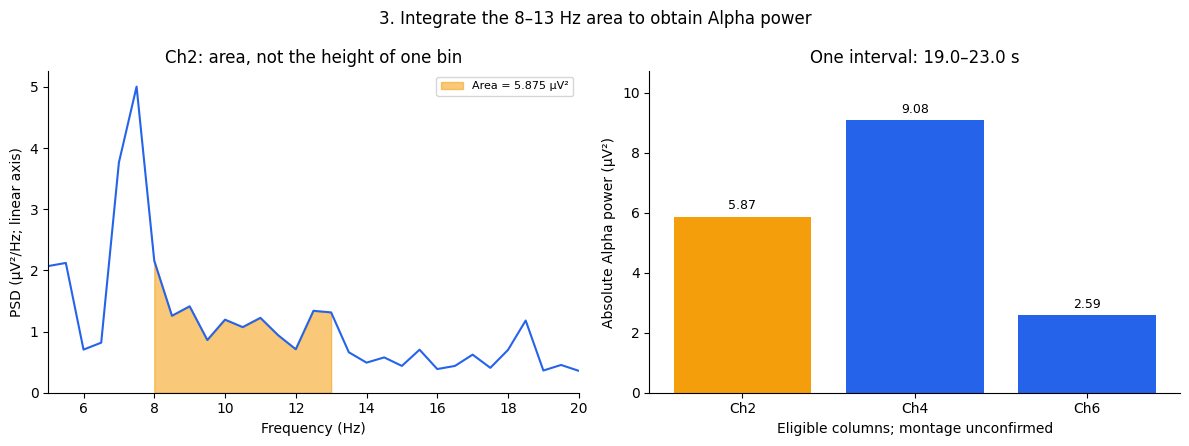

In [8]:
alpha_bins = (frequencies >= ALPHA_BAND[0]) & (frequencies <= ALPHA_BAND[1])
alpha_power_uv2 = trapezoid(example_psd[:, alpha_bins],
                           x=frequencies[alpha_bins], axis=-1)
np.testing.assert_allclose(alpha_power_uv2, integrate_band(frequencies, example_psd, band=ALPHA_BAND))
np.testing.assert_allclose(alpha_power_uv2, features["alpha_power_uv2"][eligible_indices, example_index])
for label, value in zip([CHANNEL_NAMES[i] for i in eligible_indices], alpha_power_uv2):
    print(f"{label}: 8–13 Hz power = {value:.3f} µV²")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
context_bins = (frequencies >= 5) & (frequencies <= 20)
axes[0].plot(frequencies[context_bins], spectrum[context_bins], color="#2563eb", lw=1.5)
axes[0].fill_between(frequencies[alpha_bins], spectrum[alpha_bins], color="#f59e0b", alpha=0.55,
                     label=f"Area = {alpha_power_uv2[selected_row]:.3f} µV²")
axes[0].set(xlim=(5, 20), ylim=(0, None), xlabel="Frequency (Hz)", ylabel="PSD (µV²/Hz; linear axis)",
            title=f"{CHANNEL_NAMES[ch]}: area, not the height of one bin")
axes[0].legend(fontsize=8)
bars = axes[1].bar([CHANNEL_NAMES[i] for i in eligible_indices], alpha_power_uv2,
                   color=["#f59e0b" if i == ch else "#2563eb" for i in eligible_indices])
axes[1].bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
axes[1].margins(y=0.18)
axes[1].set(ylabel="Absolute Alpha power (µV²)", xlabel="Eligible columns; montage unconfirmed",
            title=f"One interval: {start / FS:.1f}–{stop / FS:.1f} s")
fig.suptitle("3. Integrate the 8–13 Hz area to obtain Alpha power")
show_and_save(fig, "03-alpha-power.png")


## 4. Repeat the same measurement over time · 15 min

Use the **same function, channel set, frequency band, and window duration**
throughout the record. Each plotted value summarizes four seconds, and is
placed at that window's center. It is not instantaneous power.

A candidate window touching a rejected sample is not analyzed. Its value is
`NaN` (missing), so the line breaks instead of bridging the gap or dropping
to an invented zero. Bad-channel rows are missing throughout.

Four-second windows shifted by one second overlap. Report **unique time
covered**, not `number_of_windows × 4 s`, and do not count overlapping windows
as independent participants or trials. Passing the gate still does not prove
that the Alpha feature is free of all artifacts.


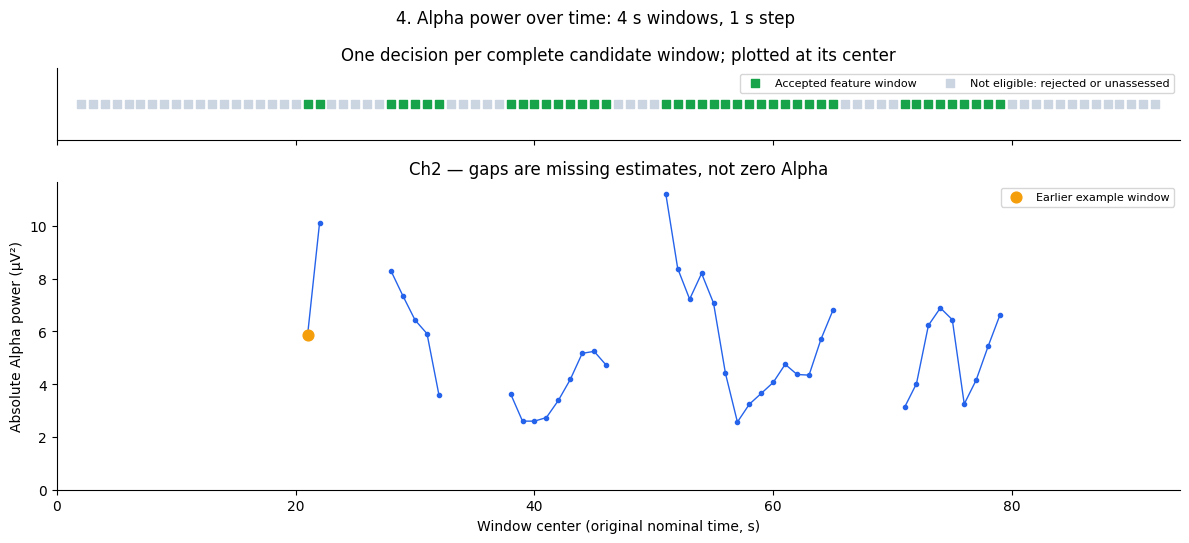

In [9]:
centers_s = features["centers_s"]
valid_windows = features["valid_window_mask"]
alpha_series = features["alpha_power_uv2"][ch]
assert np.isnan(alpha_series[~valid_windows]).all()
assert np.isnan(features["alpha_power_uv2"][bad_channel_mask]).all()
assert not np.any(features["coverage_mask"] & ~keep_mask)
fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True,
                          gridspec_kw={"height_ratios": [0.7, 3]})
for accepted, color, label in [(True, "#16a34a", "Accepted feature window"),
                                (False, "#cbd5e1", "Not eligible: rejected or unassessed")]:
    positions = centers_s[valid_windows == accepted]
    axes[0].scatter(positions, np.zeros(len(positions)), marker="s", s=28,
                    color=color, label=label)
axes[0].set(yticks=[], ylim=(-0.5, 0.5), title="One decision per complete candidate window; plotted at its center")
axes[0].legend(loc="upper right", fontsize=8, ncol=2)
axes[1].plot(centers_s, alpha_series, color="#2563eb", marker="o", markersize=3, lw=1)
axes[1].scatter([centers_s[example_index]], [alpha_series[example_index]],
                color="#f59e0b", s=60, zorder=4, label="Earlier example window")
axes[1].set(xlim=(0, n_samples / FS), ylim=(0, None), xlabel="Window center (original nominal time, s)",
            ylabel="Absolute Alpha power (µV²)", title=f"{CHANNEL_NAMES[ch]} — gaps are missing estimates, not zero Alpha")
axes[1].legend(fontsize=8)
fig.suptitle(f"4. Alpha power over time: {FEATURE_WINDOW_S:g} s windows, {STEP_S:g} s step")
show_and_save(fig, "04-alpha-over-time.png")


## Optional learning extension — relative Alpha, not an attention score

For the same example interval, divide 8–13 Hz power by 1–45 Hz power:

`relative Alpha = Alpha power / total power in the stated reference band`

This fraction has no physical unit. Its value depends on the denominator and
preprocessing, so always state both. If reference-band power is zero, the
ratio is undefined, not zero. **Run All executes this short calculation too**;
a core-only class can run the notebook normally and skip discussing this section.

We deliberately **do not estimate an Alpha peak** here. Searching for the
largest bin always returns a frequency, even on a spectrum with no distinct
peak. A dedicated peak-detection method and criterion would be another task.
Alpha-band power alone does not establish a rhythmic peak, relaxation,
attention, or a health condition.


In [10]:
reference_band = (1.0, 45.0)
reference_power_uv2 = integrate_band(frequencies, example_psd, band=reference_band)
relative_alpha = np.full_like(alpha_power_uv2, np.nan)
np.divide(alpha_power_uv2, reference_power_uv2, out=relative_alpha, where=reference_power_uv2 > 0)
print("OPTIONAL: relative Alpha; denominator = power integrated over 1–45 Hz")
for label, value in zip([CHANNEL_NAMES[i] for i in eligible_indices], relative_alpha):
    print(f"{label}: {value:.3f}" if np.isfinite(value) else f"{label}: undefined (zero reference power)")
print("No rhythmic peak, condition, or cognitive-state label has been inferred.")


OPTIONAL: relative Alpha; denominator = power integrated over 1–45 Hz
Ch2: 0.031
Ch4: 0.022
Ch6: 0.020
No rhythmic peak, condition, or cognitive-state label has been inferred.


In [11]:
import scipy
import matplotlib

summary = {
    "lesson": 4, "mode": "replay", "synthetic": False,
    "source_sha256": SOURCE_SHA256,
    "quality_source_commit": "e3539cbeca99e824dfeb3ebdb44d80ca80f0d5dc",
    "psd_source": "S2 calculate_eeg_psd per-channel Welch loop; continuous-input adaptation",
    "original_psd_function_sha256": "01563a3e193d45bae4e5c7f7220e92a369b0f3e63b46d678a48222454743d91a",
    "amplitude_unit": "uV", "unit_confirmed": unit_confirmed,
    "unit_confirmation_basis": ("owner confirmation on 2026-09-21; matched SHA-256"
                                if SOURCE_SHA256 in CONFIRMED_UV_HASHES and UNIT_CONFIRMED is None
                                else "explicit notebook setting"),
    "shape_channels_by_samples": list(data.shape),
    "malformed_row_count": len(info["malformed_rows"]),
    "channel_mapping": "unconfirmed; column labels only",
    "channel_labels": CHANNEL_NAMES,
    "conditions": "unconfirmed; no eyes-open/eyes-closed comparison",
    "packet_clock_summary": timing, "p_field_summary": p_summary,
    "time_axis": "original nominal sample index / 250; no interpolation or concatenation",
    "preprocessing": "reuse Lesson 3 1–50 Hz filtfilt result; no second filtering",
    "quality_gate": gate["summary"],
    "feature_summary": features["summary"],
    "psd_unit": "uV^2/Hz", "band_power_unit": "uV^2", "alpha_band_hz": list(ALPHA_BAND),
    "frequency_spacing_hz": frequency_spacing_hz,
    "display_channel": CHANNEL_NAMES[ch],
    "selection_rule": "first eligible column and first accepted feature window by default; never largest Alpha",
    "example_interval": {"start_sample": start, "stop_sample_exclusive": stop,
                         "start_s": start / FS, "stop_s": stop / FS,
                         "accepted_window_index": EXAMPLE_WINDOW},
    "example_alpha_power_uv2": {CHANNEL_NAMES[i]: float(value)
                                for i, value in zip(eligible_indices, alpha_power_uv2)},
    "optional_relative_alpha": {"reference_band_hz": list(reference_band),
                                "values": {CHANNEL_NAMES[i]: float(value) if np.isfinite(value) else None
                                           for i, value in zip(eligible_indices, relative_alpha)}},
    "peak_estimation": "not performed; band power does not establish a distinct peak",
    "figures": FIGURES,
    "software": {"python": sys.version.split()[0], "numpy": np.__version__,
                 "scipy": scipy.__version__, "matplotlib": matplotlib.__version__},
    "limitations": ["sensor-column, within-recording descriptive features only",
                    "overlapping windows are not independent trials",
                    "QC acceptance is not proof of artifact-free brain activity",
                    "original clock irregularities remain; no live-device validation"],
}
(OUTPUT_DIR / "summary.json").write_text(json.dumps(summary, indent=2, allow_nan=False), encoding="utf-8")
np.savez_compressed(OUTPUT_DIR / "alpha-features.npz", starts=features["starts"], stops=features["stops"],
                    centers_s=centers_s, valid_window_mask=valid_windows,
                    alpha_power_uv2=features["alpha_power_uv2"], coverage_mask=features["coverage_mask"],
                    bad_channel_mask=bad_channel_mask)
print("Saved four figures, summary.json, and alpha-features.npz under:")
print(OUTPUT_DIR.relative_to(ROOT))
print("Local outputs are ignored by Git. Original recordings and tracked notebook outputs are unchanged.")


Saved four figures, summary.json, and alpha-features.npz under:
outputs\notebooks\lesson-04
Local outputs are ignored by Git. Original recordings and tracked notebook outputs are unchanged.


## Check your understanding

1. Why are PSD and integrated Alpha power expressed in different units?
2. Why does a four-second feature window use two-second Welch segments here?
3. Why does a gap in the Alpha curve not mean that Alpha power became zero?
4. Does a nonzero 8–13 Hz power value prove a distinct Alpha oscillation?
5. Why can the feature-covered duration be shorter than the duration accepted by QC?

**Small exercise:** choose another eligible `CHANNEL_INDEX` or increment
`EXAMPLE_WINDOW` within the accepted-window list. Rerun and explain the
numerical and graphical changes without changing QC thresholds. There is
no required direction of change and no required 10 Hz peak.

**Deliverable:** one shaded PSD figure, the Alpha power with units, the
channel and interval, accepted/feature-covered durations, and two limitations.
**Lesson 5** takes this feature into the official
[NeuraDock Agent](https://github.com/Neuradock/eeg-workstation-agent).
You will inspect its quality-gated Alpha display and rolling reference;
live feedback from your own EEG requires the supported NeuraDock device.

Source details: `docs/lesson04-source.md`. No raw-data publication, live
hardware connection, or inference about cognitive or clinical state is made.
